In [1]:
from RamanModel import *
from HelperFunctions import *

# Create an example spectrum

We create a single example of a spectrum

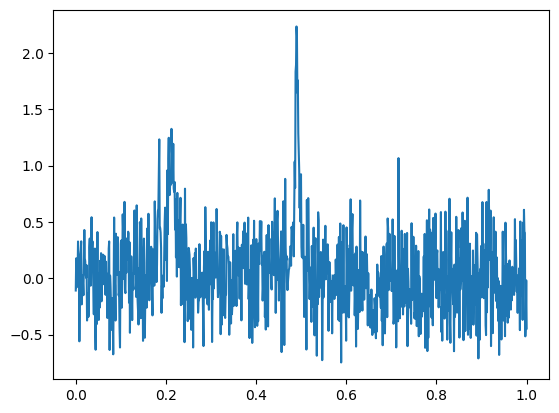

In [53]:
import numpy as np
import matplotlib.pyplot as plt

parameters = {
    "center_range": (0, 1),
    "amplitude_range": (0.1, 1),
    "gamma_range": (0.001, 0.01),
    "x_min": 0,
    "x_max": 1
}

x = np.linspace(0, 1, 1000)
x, y, params = generateCurve(parameters, 4, len(x), noise_sigma=0.3)
plt.plot(x, y)

# Run Simulated Annealing

Running simulated annealing to generate heatmap

In [54]:
energy, index, map = simulated_annealing(y, kmax=100, max_temp=0.5, cooling_factor=400, samples=100, num_repetitions=200)

In [55]:
flattened = flatten_SA_map(map, len(y), samples_per_pixel=3, function=log_transform)

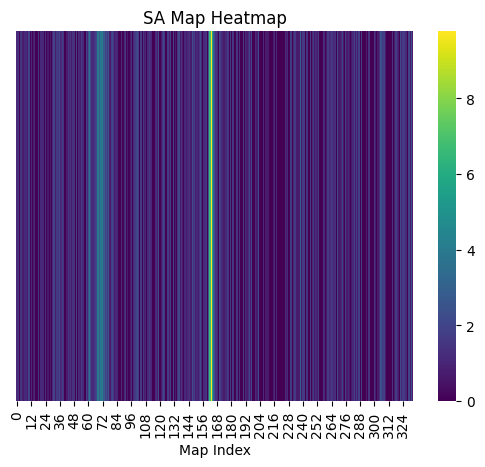

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.heatmap(flattened.reshape(1, -1), cmap="viridis", cbar=True)

plt.title("SA Map Heatmap")
plt.xlabel("Map Index")
plt.yticks([])

plt.show()


Generated Curve Parameters:
-------------------------------------------------------
Peak ID    | Center       | Amplitude    | Gamma       
-------------------------------------------------------
0          | 0.4908       | 0.9930       | 0.0051      
1          | 0.2129       | 0.6203       | 0.0081      
2          | 0.1828       | 0.4432       | 0.0022      
3          | 0.9168       | 0.2290       | 0.0018      
-------------------------------------------------------



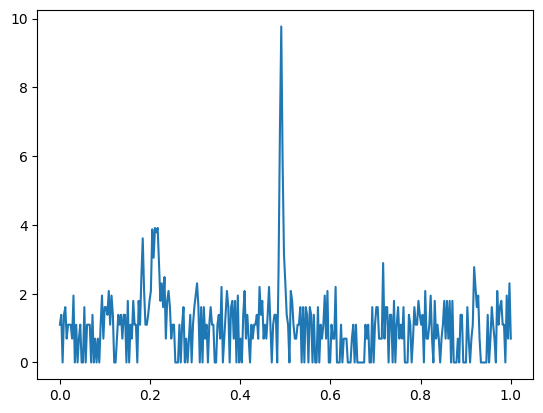

In [57]:
flattened_x = np.linspace(0, 1, (len(y)//3))
plt.plot(flattened_x, flattened)
print_peak_params(params)

In [ ]:
# TODO: Test adding weight related to the temperature to makes these differences even more significant.